In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Metrics



In [2]:
ROOT = "./g2/metrics/"
csv_files = {
    'product_service': ROOT + 'product-service.csv',
    'cart_service':   ROOT + 'cart-service.csv',
    'payment_service':  ROOT + 'payment-service.csv',
    'order_service':  ROOT + 'order-service.csv',
    'api_gateway':  ROOT +  'api-gateway.csv'
}

dfs = {}

for name, path in csv_files.items():
    try:
        df = pd.read_csv(path)
        if 'timestamp' in df.columns:
            # Convert 'timestamp' column to datetime, assuming UTC if not specified
            df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
            print(f"\n--- Statistics for {name} ---")
            print(f"Successfully loaded and converted 'timestamp' for {name}")
            print(f"Number of rows: {df.shape[0]}")
            print(f"Number of columns: {df.shape[1]}")
            print("Descriptive statistics:")
            print(df.describe(include='all')) # include='all' to get statistics for all data types
        else:
            print(f"'timestamp' column not found in {name}")
            print(f"\n--- Statistics for {name} ---")
            print(f"Number of rows: {df.shape[0]}")
            print(f"Number of columns: {df.shape[1]}")
            print("Descriptive statistics:")
            print(df.describe(include='all'))
        dfs[name] = df
    except FileNotFoundError:
        print(f"Error: File not found at {path}")
    except Exception as e:
        print(f"Error processing {name}: {e}")

# Example of accessing a processed DataFrame:
# print(dfs['cart_service'].head())
# print(dfs['cart_service']['timestamp'].dtype)


--- Statistics for product_service ---
Successfully loaded and converted 'timestamp' for product_service
Number of rows: 2820
Number of columns: 5
Descriptive statistics:
                              timestamp  http_requests_per_sec  \
count                              2820            2820.000000   
mean   2026-06-01 12:00:04.148936+00:00              37.701397   
min           2026-06-01 00:00:00+00:00              13.780000   
25%    2026-06-01 05:52:22.500000+00:00              30.590000   
50%           2026-06-01 12:14:45+00:00              36.865000   
75%    2026-06-01 18:07:07.500000+00:00              44.532500   
max           2026-06-01 23:59:30+00:00              65.820000   
std                                 NaN               9.403785   

       http_p99_latency_ms  cpu_usage_percent  http_5xx_rate  
count          2820.000000        2820.000000    2820.000000  
mean             70.053582          21.556823       0.754635  
min              20.000000           2.00000

# Load Log

In [3]:
import json

log_files = {
    'order_service': './g2/logs/order-service.log.jsonl',
    'cart_service': './g2/logs/cart-service.log.jsonl'
}

all_logs = []

for service_name, path in log_files.items():
    try:
        with open(path, 'r') as f:
            for line in f:
                try:
                    log_entry = json.loads(line)
                    log_entry['service'] = service_name # Add service name for context
                    all_logs.append(log_entry)
                except json.JSONDecodeError as e:
                    print(f"Error decoding JSON from {path}: {e} in line: {line.strip()}")
    except FileNotFoundError:
        print(f"Error: Log file not found at {path}")
    except Exception as e:
        print(f"Error processing {path}: {e}")

# Create a DataFrame from all logs
log_df = pd.DataFrame(all_logs)

# Convert timestamp to datetime objects, handling potential different formats
# errors='coerce' will turn invalid date parsing into NaT (Not a Time)
log_df['timestamp'] = pd.to_datetime(log_df['timestamp'], errors='coerce', utc=True)

# Drop rows where timestamp conversion failed
log_df.dropna(subset=['timestamp'], inplace=True)

print("\nLog Level Statistics:")
print(log_df['level'].value_counts())

print("\nLog Level Statistics by Service:")
print(log_df.groupby('service')['level'].value_counts().unstack(fill_value=0))

print("\nTotal log entries loaded:", len(log_df))


Log Level Statistics:
level
INFO     19479
WARN      9938
ERROR     1896
FATAL      819
Name: count, dtype: int64

Log Level Statistics by Service:
level          ERROR  FATAL   INFO  WARN
service                                 
cart_service    1458    819  13078  8920
order_service    438      0   6401  1018

Total log entries loaded: 32132


# Raw Plot & Histogram

Generating plots for cart_service...


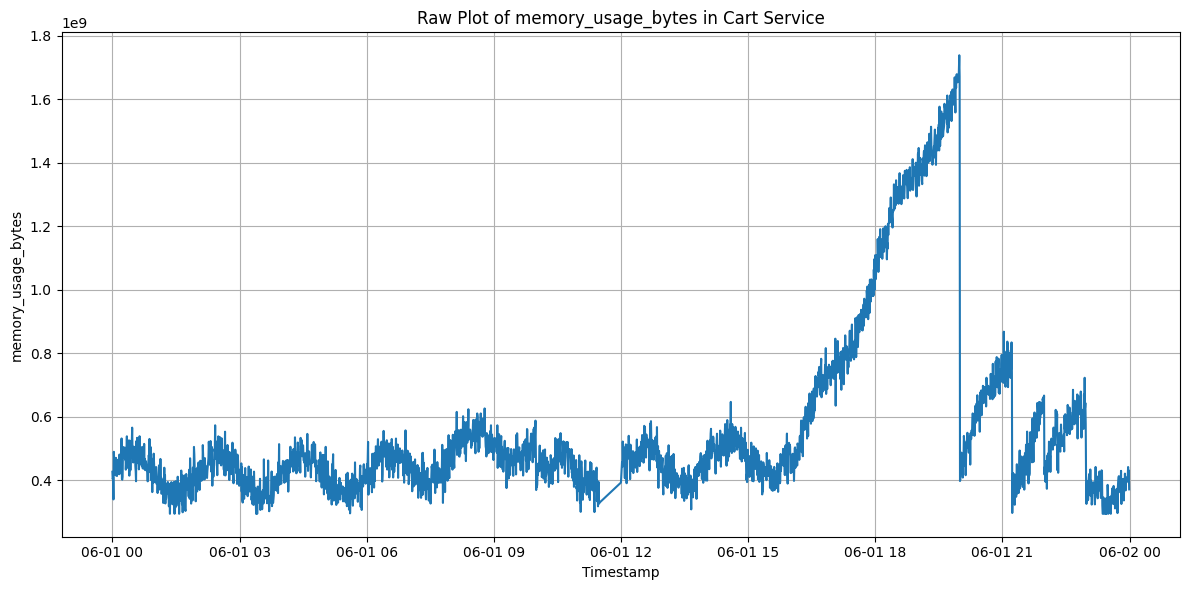

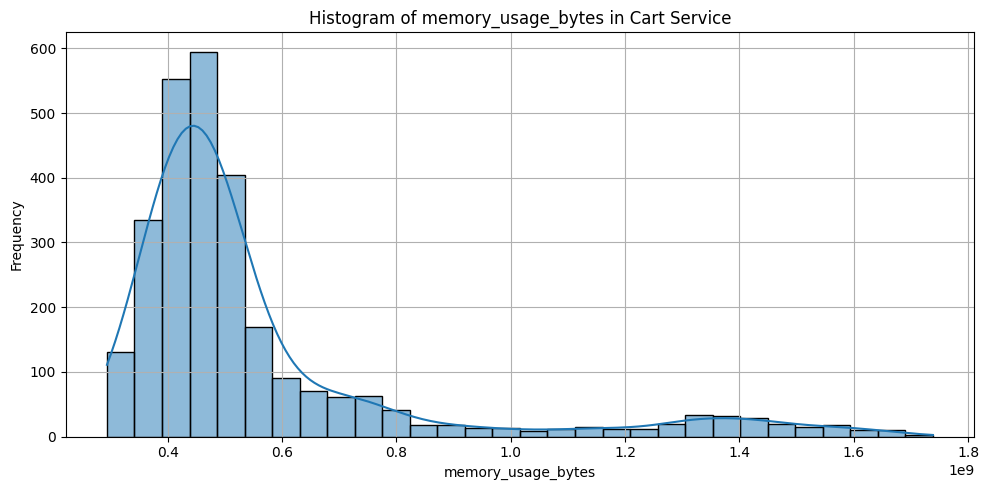

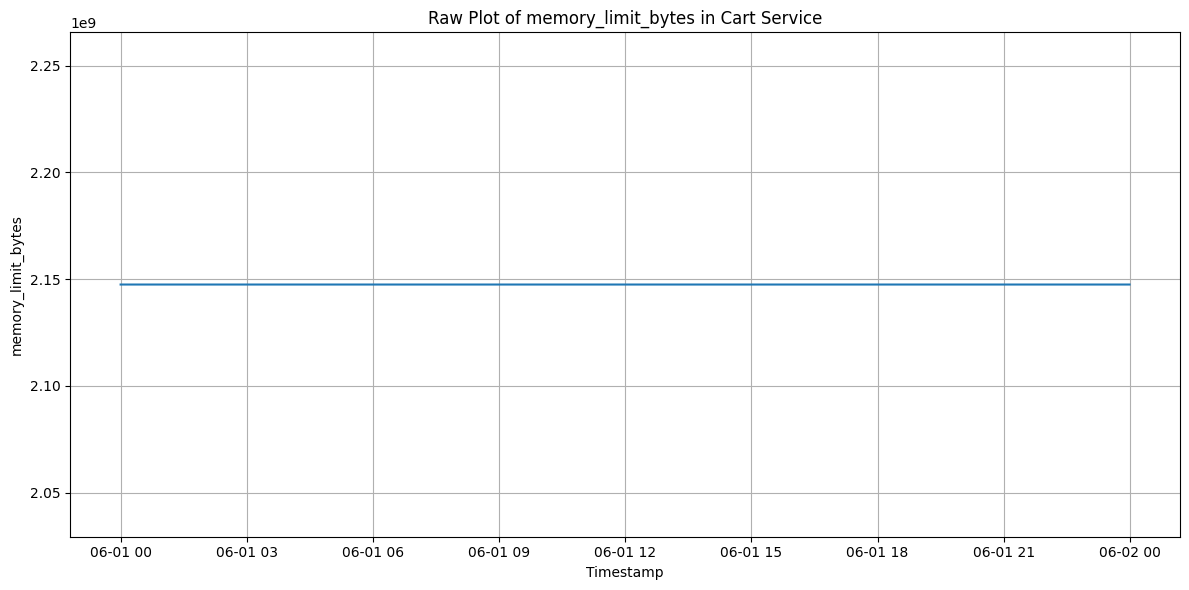

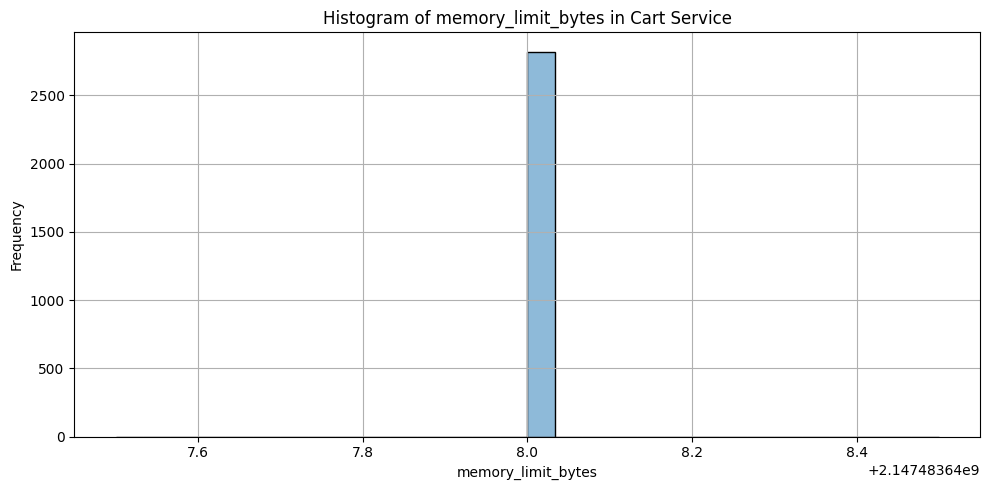

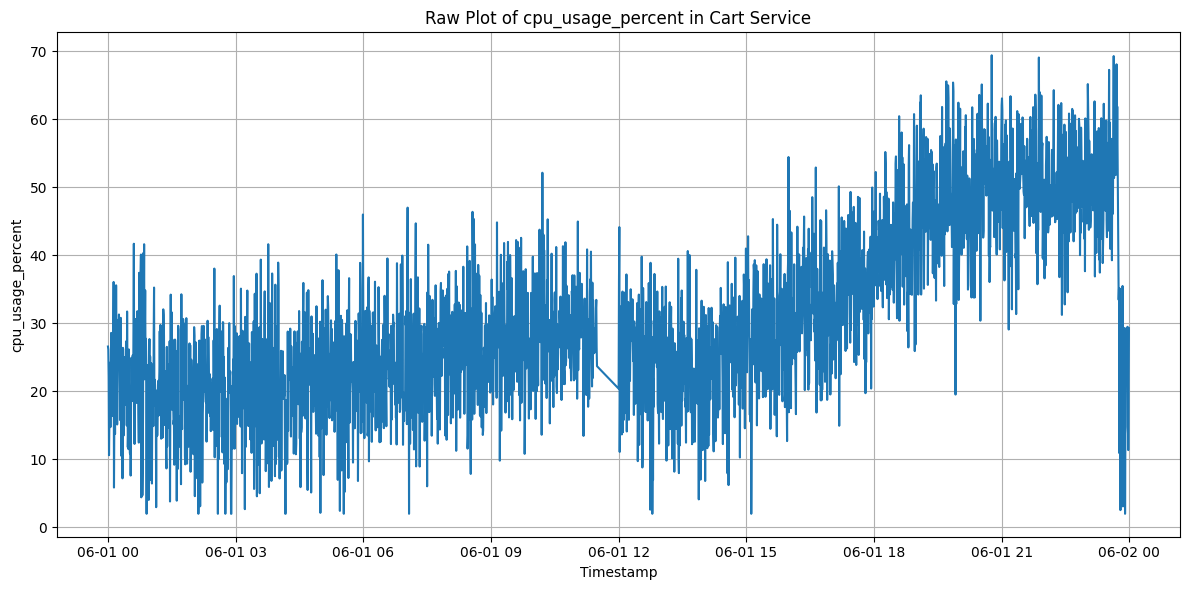

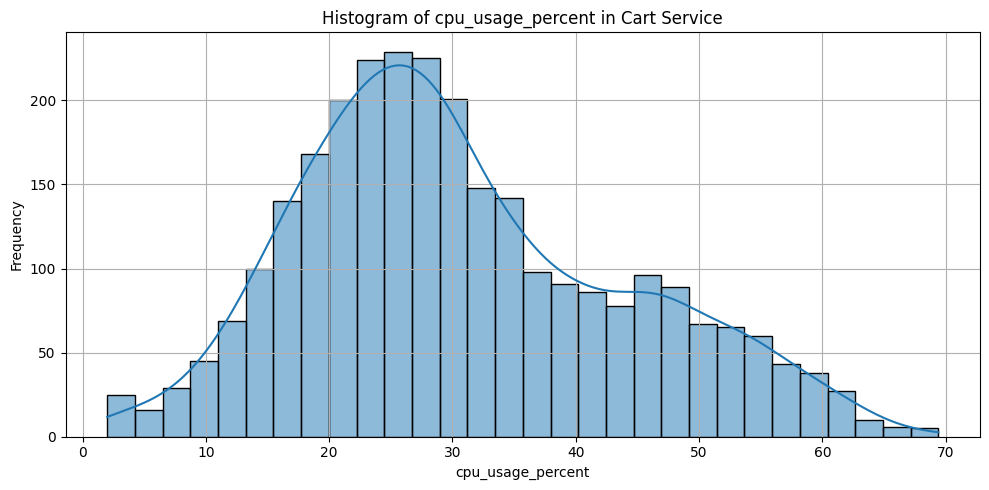

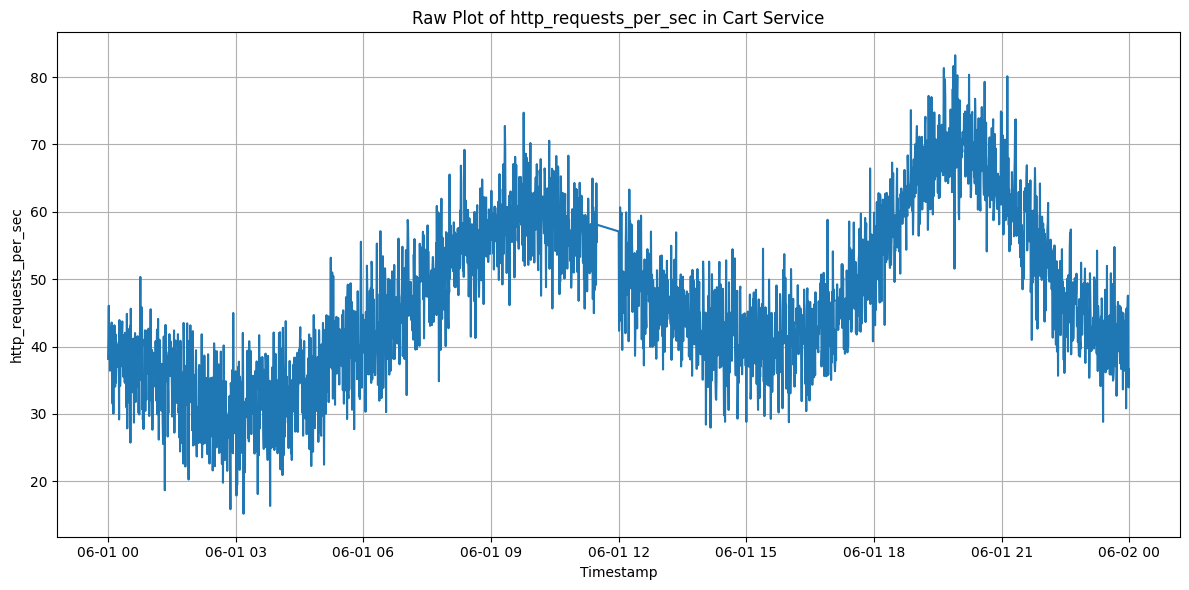

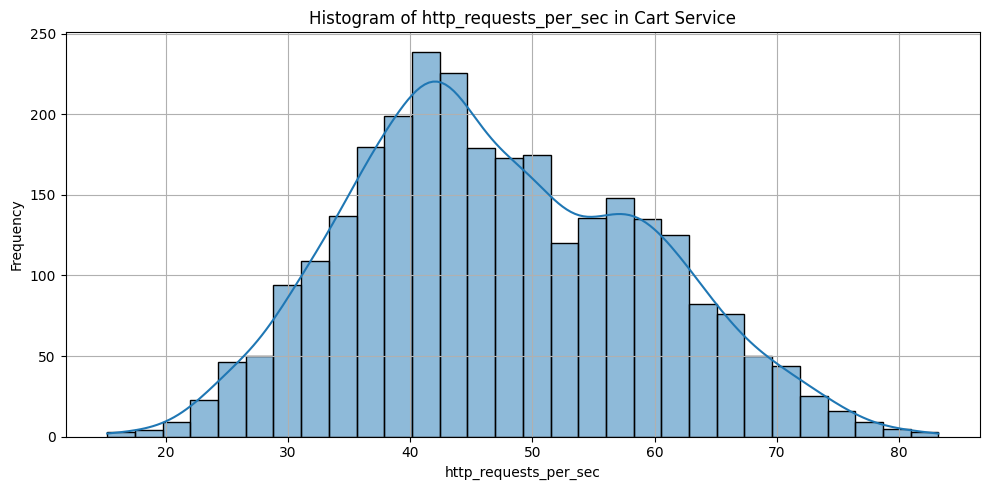

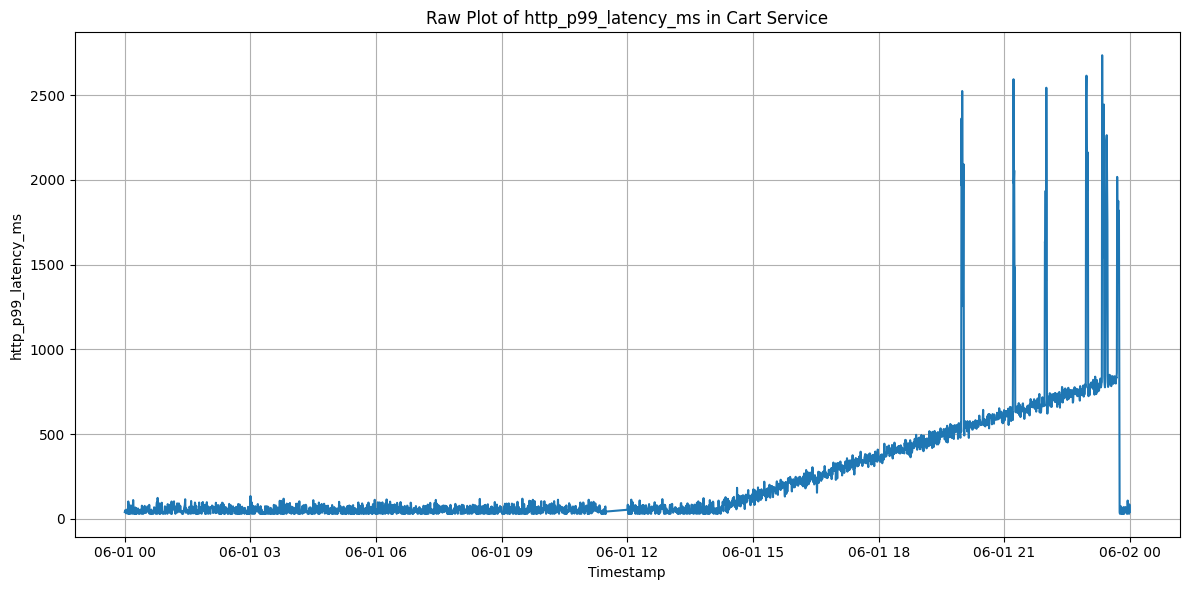

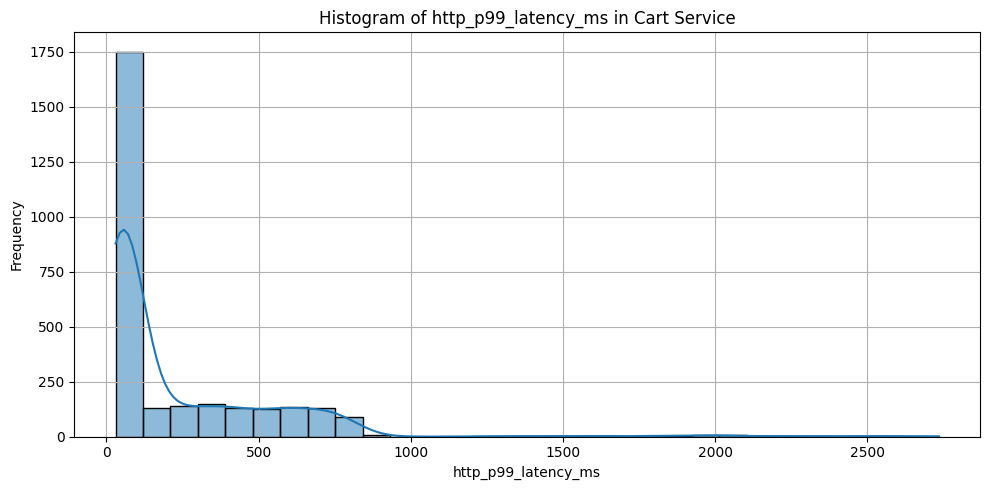

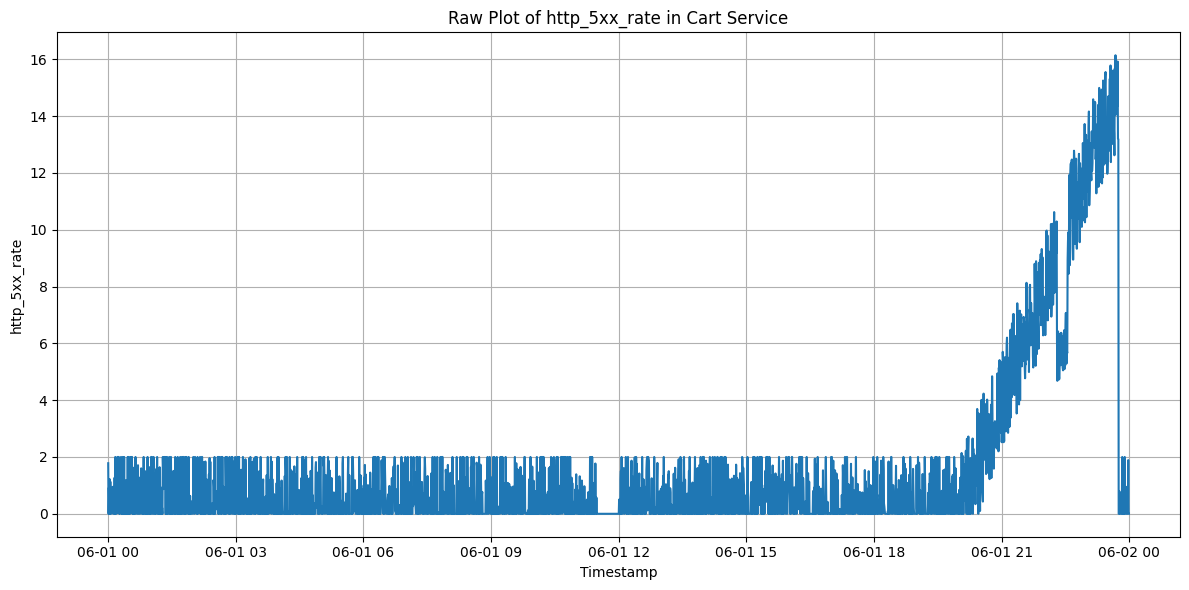

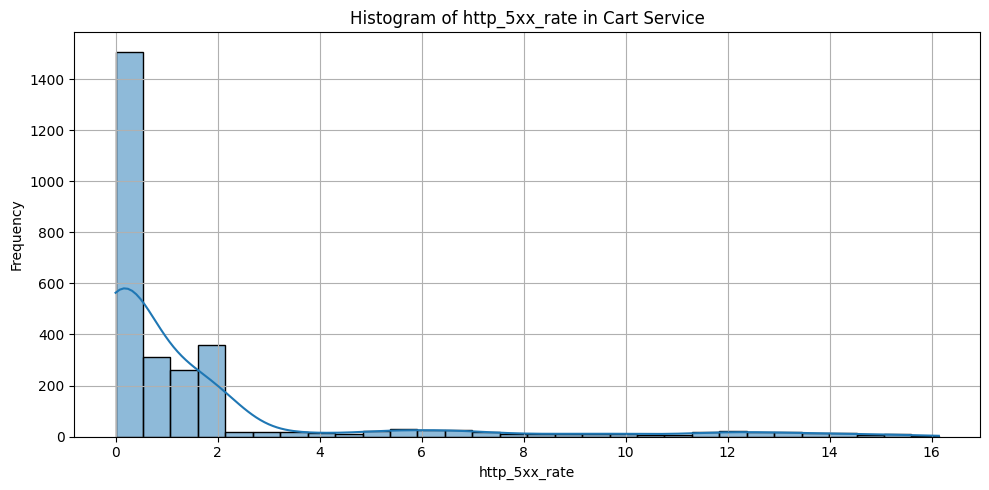

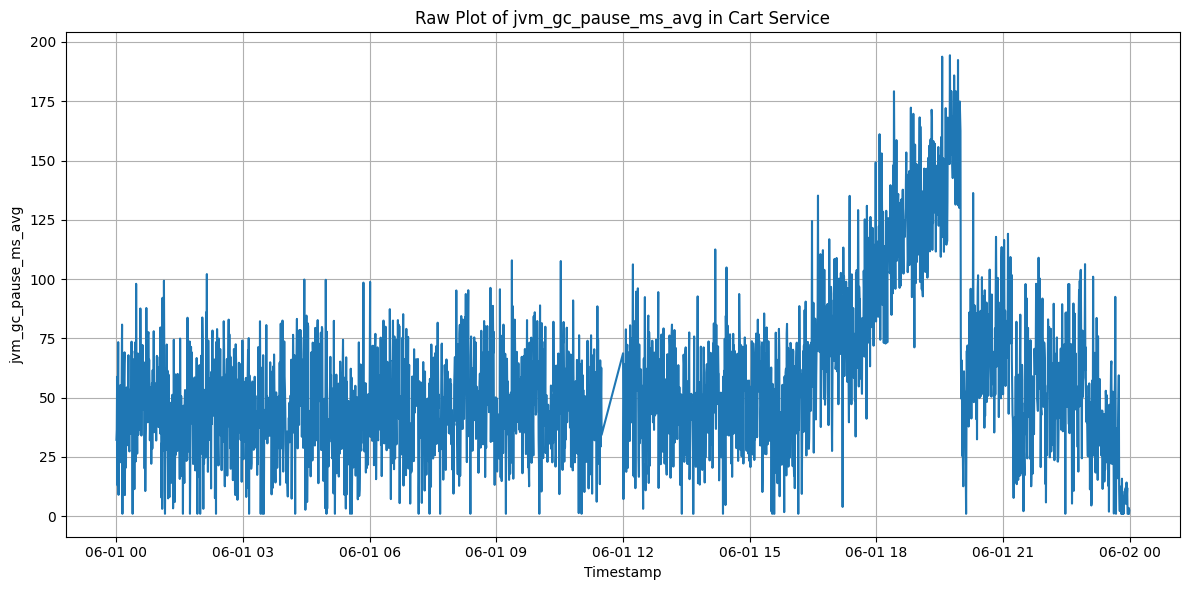

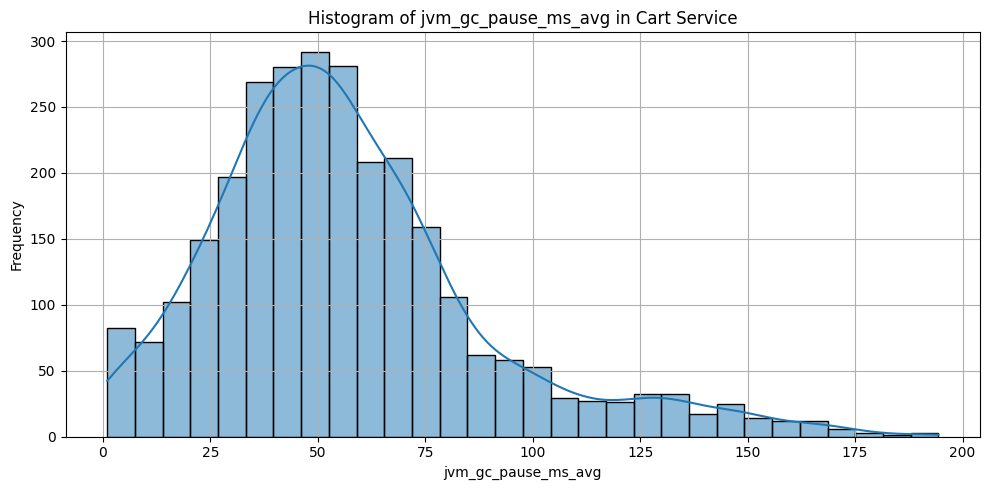

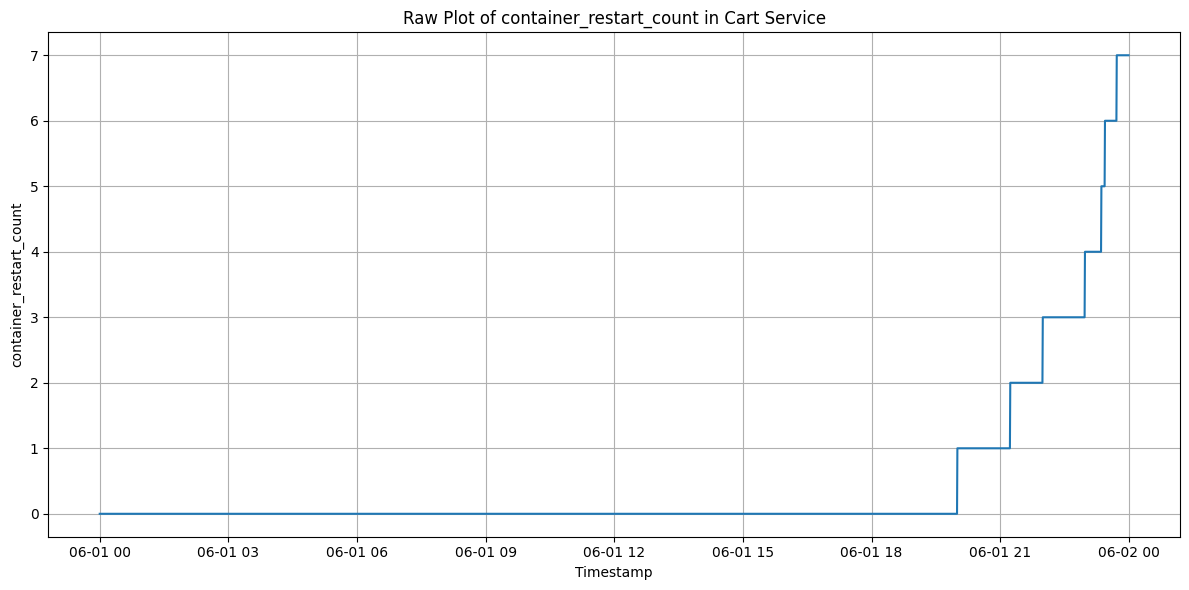

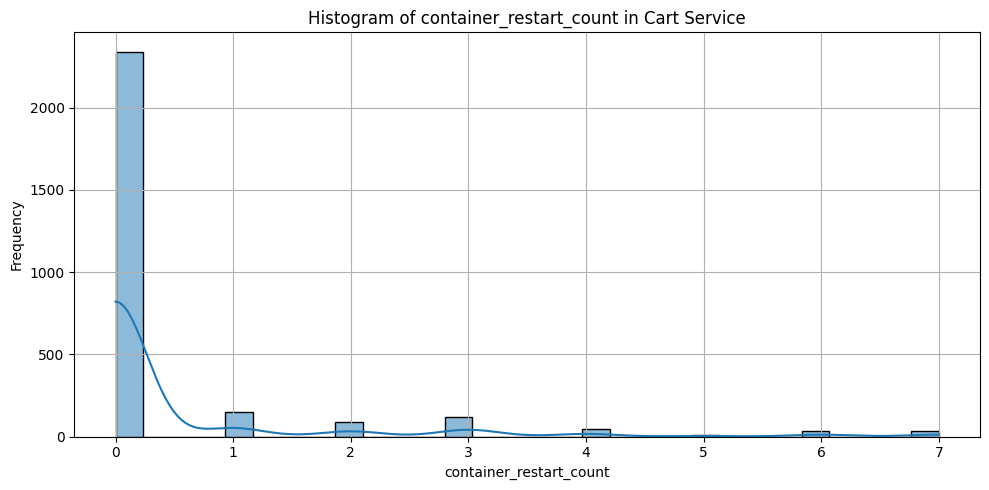

Finished generating plots for cart_service.


In [4]:
cart_df = dfs['cart_service']

# Identify numerical columns for plotting, excluding 'timestamp'
numerical_cols = cart_df.select_dtypes(include=np.number).columns.tolist()

print("Generating plots for cart_service...")

for col in numerical_cols:
    # Raw Plot (Line Plot)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=cart_df, x='timestamp', y=col)
    plt.title(f'Raw Plot of {col} in Cart Service')
    plt.xlabel('Timestamp')
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Histogram
    plt.figure(figsize=(10, 5))
    sns.histplot(cart_df[col], kde=True, bins=30)
    plt.title(f'Histogram of {col} in Cart Service')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("Finished generating plots for cart_service.")

# 5xx Error Spike

In [5]:
df = dfs['cart_service']
df_evening = df[df['timestamp'].dt.hour >= 18]
threshold_breach = df_evening[df_evening['http_5xx_rate'] > 5]

threshold_breach

,timestamp,memory_usage_bytes,memory_limit_bytes,cpu_usage_percent,http_requests_per_sec,http_p99_latency_ms,http_5xx_rate,jvm_gc_pause_ms_avg,container_restart_count
2452,2026-06-01 20:56:00+00:00,671843737,2147483648,45.89,61.37,607.6,5.14,50.3,1
2454,2026-06-01 20:57:00+00:00,710359064,2147483648,47.09,62.64,602.6,5.41,49.7,1
2459,2026-06-01 20:59:30+00:00,735384409,2147483648,57.31,61.07,641.5,5.33,78.1,1
2463,2026-06-01 21:01:30+00:00,706370791,2147483648,44.00,71.35,602.5,5.70,116.5,1
2464,2026-06-01 21:02:00+00:00,867530194,2147483648,56.34,62.62,635.9,5.39,82.5,1
...,...,...,...,...,...,...,...,...,...
2785,2026-06-01 23:42:30+00:00,372608842,2147483648,54.91,35.79,1793.3,15.47,37.2,6
2786,2026-06-01 23:43:00+00:00,295844585,2147483648,61.86,40.23,1875.8,14.34,16.0,7
2787,2026-06-01 23:43:30+00:00,377315870,2147483648,54.26,40.64,1397.2,15.92,38.8,7
2788,2026-06-01 23:44:00+00:00,397325796,2147483648,47.14,46.63,1818.3,13.20,48.4,7


# Cảnh báo sớm (Silent Signal)

In [6]:
# Z-score
baseline = df[df['timestamp'].dt.hour < 12]['http_5xx_rate']
mean_base = baseline.mean()
std_base = baseline.std()

df['z_score'] = (df['http_5xx_rate'] - mean_base) / std_base
silent_signal = df[(df['timestamp'].dt.hour >= 18) & (df['z_score'] > 3)].iloc[0]

silent_signal

timestamp                  2026-06-01 20:25:30+00:00
memory_usage_bytes                         644277395
memory_limit_bytes                        2147483648
cpu_usage_percent                              53.03
http_requests_per_sec                           71.7
http_p99_latency_ms                            575.5
http_5xx_rate                                   3.69
jvm_gc_pause_ms_avg                             86.4
container_restart_count                            1
z_score                                     4.256724
Name: 2391, dtype: object

## Anomaly Detection
Implementing Z-Score and Isolation Forest for detecting anomalies in the `cart-service`.

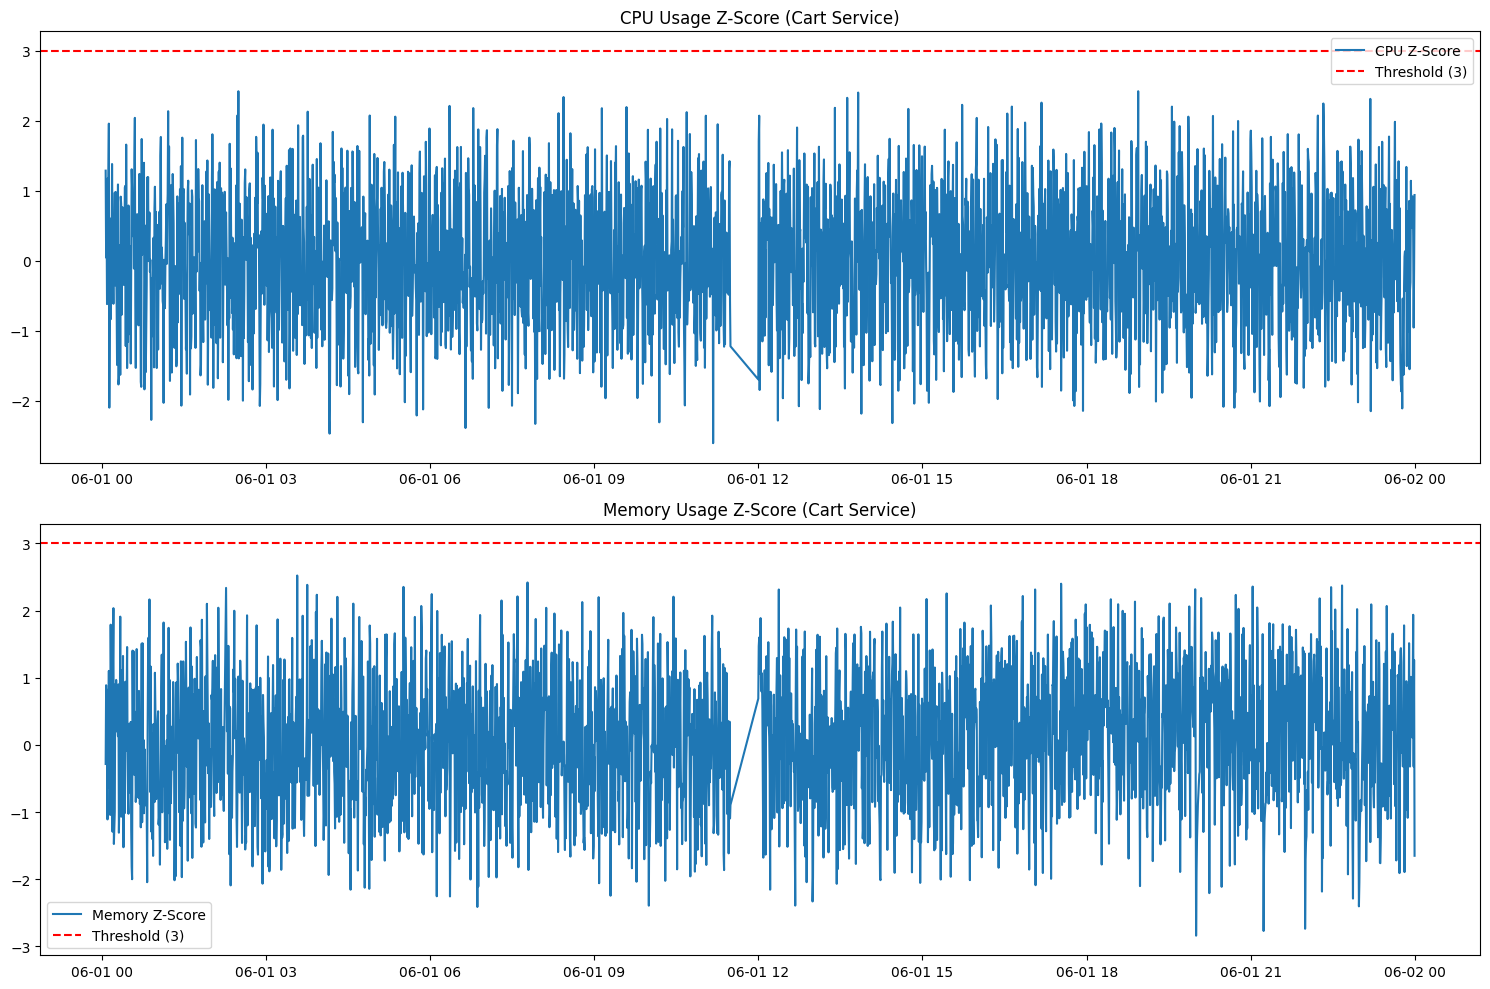

Earliest CPU anomaly: NaT
Earliest Memory anomaly: NaT


In [7]:
# Moving Z-Score for CPU and Memory of cart-service
cart_df = dfs['cart_service'].copy()
cart_df.set_index('timestamp', inplace=True)

window_size = 10 # 5 minutes (30s interval)
cart_df['cpu_rolling_mean'] = cart_df['cpu_usage_percent'].rolling(window=window_size).mean()
cart_df['cpu_rolling_std'] = cart_df['cpu_usage_percent'].rolling(window=window_size).std()
cart_df['cpu_z_score'] = (cart_df['cpu_usage_percent'] - cart_df['cpu_rolling_mean']) / cart_df['cpu_rolling_std']

cart_df['mem_rolling_mean'] = cart_df['memory_usage_bytes'].rolling(window=window_size).mean()
cart_df['mem_rolling_std'] = cart_df['memory_usage_bytes'].rolling(window=window_size).std()
cart_df['mem_z_score'] = (cart_df['memory_usage_bytes'] - cart_df['mem_rolling_mean']) / cart_df['mem_rolling_std']

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
axes[0].plot(cart_df.index, cart_df['cpu_z_score'], label='CPU Z-Score')
axes[0].axhline(3, color='r', linestyle='--', label='Threshold (3)')
axes[0].set_title('CPU Usage Z-Score (Cart Service)')
axes[0].legend()

axes[1].plot(cart_df.index, cart_df['mem_z_score'], label='Memory Z-Score')
axes[1].axhline(3, color='r', linestyle='--', label='Threshold (3)')
axes[1].set_title('Memory Usage Z-Score (Cart Service)')
axes[1].legend()
plt.tight_layout()
plt.show()

# Find the earliest anomaly
print("Earliest CPU anomaly:", cart_df[cart_df['cpu_z_score'] > 3].index.min())
print("Earliest Memory anomaly:", cart_df[cart_df['mem_z_score'] > 3].index.min())

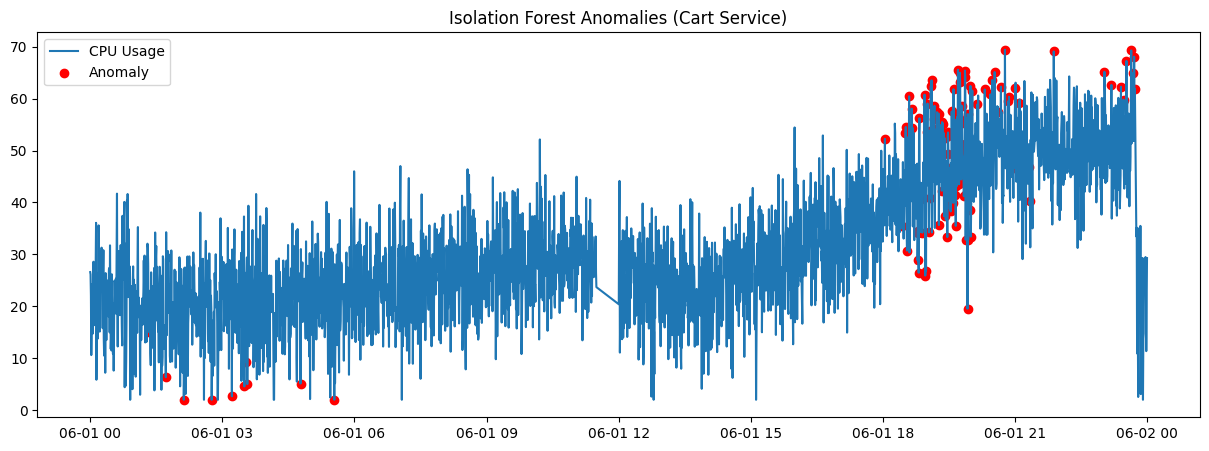

Earliest IF anomaly: 2026-06-01 01:20:00+00:00


In [8]:
from sklearn.ensemble import IsolationForest

features = ['cpu_usage_percent', 'memory_usage_bytes', 'http_requests_per_sec']
X = cart_df[features].dropna()

clf = IsolationForest(contamination=0.05, random_state=42)
cart_df['anomaly_if'] = np.nan
cart_df.loc[X.index, 'anomaly_if'] = clf.fit_predict(X)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(cart_df.index, cart_df['cpu_usage_percent'], label='CPU Usage')
anomalies = cart_df[cart_df['anomaly_if'] == -1]
ax.scatter(anomalies.index, anomalies['cpu_usage_percent'], color='red', label='Anomaly')
ax.set_title('Isolation Forest Anomalies (Cart Service)')
ax.legend()
plt.show()

print("Earliest IF anomaly:", anomalies.index.min())

## Log Analysis
Extracting signals from logs and finding the root cause indicator.

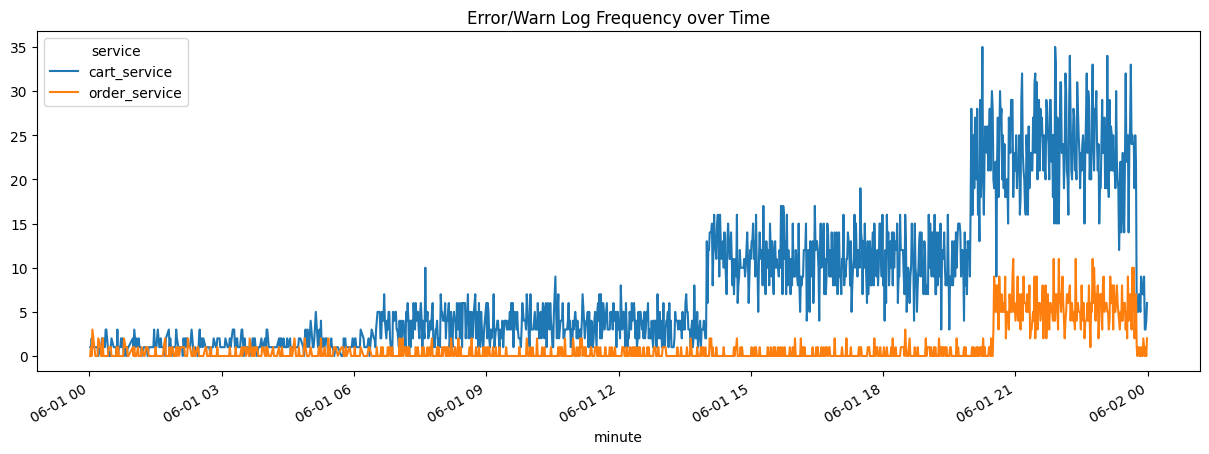

Cart Service ERROR logs around the first anomaly time:
message
OutOfMemoryError imminent: available heap < 5%      775
Upstream connection refused host=product-service    409
Name: count, dtype: int64

Cart Service FATAL logs (indicating container crash):
message
Container OOMKilled: memory limit exceeded    819
Name: count, dtype: int64

First Error in Cart Service:
Time: 2026-06-01 19:59:00.382000+00:00, Message: OutOfMemoryError imminent: available heap < 5%


In [9]:
# Analyze logs to find early indicators
error_logs = log_df[log_df['level'].isin(['ERROR', 'FATAL', 'WARN'])].copy()

error_logs['minute'] = error_logs['timestamp'].dt.floor('Min')
error_counts = error_logs.groupby(['service', 'minute']).size().unstack(level=0, fill_value=0)

fig, ax = plt.subplots(figsize=(15, 5))
error_counts.plot(ax=ax)
ax.set_title('Error/Warn Log Frequency over Time')
plt.show()

cart_errors = error_logs[(error_logs['service'] == 'cart_service') & (error_logs['level'] == 'ERROR')]
print("Cart Service ERROR logs around the first anomaly time:")
early_errors = cart_errors[cart_errors['timestamp'] < '2026-06-01 23:04:00+00:00']
print(early_errors['message'].value_counts().head())

# Look at FATAL logs as well
cart_fatal = error_logs[(error_logs['service'] == 'cart_service') & (error_logs['level'] == 'FATAL')]
print("\nCart Service FATAL logs (indicating container crash):")
print(cart_fatal['message'].value_counts().head())

if not early_errors.empty:
    first_error = early_errors.sort_values('timestamp').iloc[0]
    print("\nFirst Error in Cart Service:")
    print(f"Time: {first_error['timestamp']}, Message: {first_error['message']}")
